# Tech Challenge - Fase 1
## Análise de NPS em E-commerce

### Objetivo
Este notebook apresenta a análise exploratória de uma base de dados de clientes de um e-commerce, com o objetivo de identificar os fatores que influenciam a satisfação dos consumidores, medida pelo Net Promoter Score (NPS). Além da EDA, é proposta uma solução baseada em Machine Learning para prever a satisfação dos clientes antes da aplicação da pesquisa de NPS.

## **1. Importação das bibliotecas**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## **2. Carregamento da base de dados**

In [2]:
df = pd.read_csv('/content/desafio_nps_fase_1.csv')

## **3. Conhecendo a base de dados**
Nesta etapa são apresentadas as principais características da base de dados, incluindo sua estrutura, tipos de variáveis e estatísticas descritivas.

In [3]:
df.shape

(2500, 19)

In [4]:
df.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [6]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


## **4. Qualidade dos dados**
Nesta etapa é verificada a existência de valores ausentes na base de dados.

In [7]:
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


### **Resultado:** Não foram encontrados valores nulos na base de dados, indicando boa qualidade inicial para as análises.

## **5. Distribuição do NPS**
Nesta etapa, os clientes são classificados em detratores, neutros e promotores, conforme a metodologia do Net Promoter Score (NPS). Em seguida, é analisada a distribuição dessas categorias na base de dados.

In [8]:
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

In [9]:
df['nps_categoria'].value_counts()

,count
nps_categoria,
Detrator,1851
Neutro,448
Promotor,201


In [10]:
round(df['nps_categoria'].value_counts(normalize=True) * 100, 2)

,proportion
nps_categoria,
Detrator,74.04
Neutro,17.92
Promotor,8.04


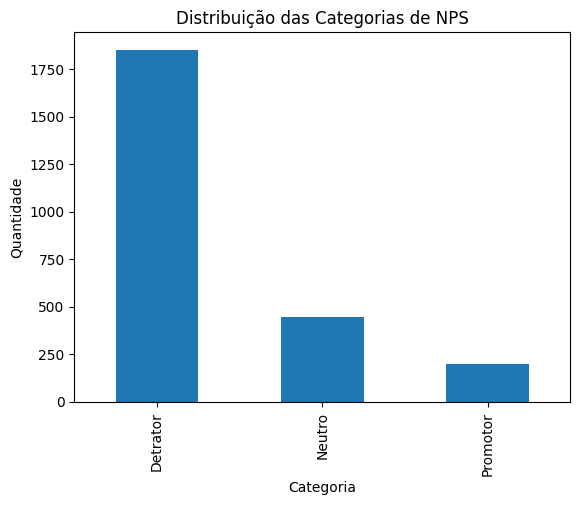

In [11]:
df['nps_categoria'].value_counts().plot(kind='bar')

plt.title('Distribuição das Categorias de NPS')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')

plt.show()

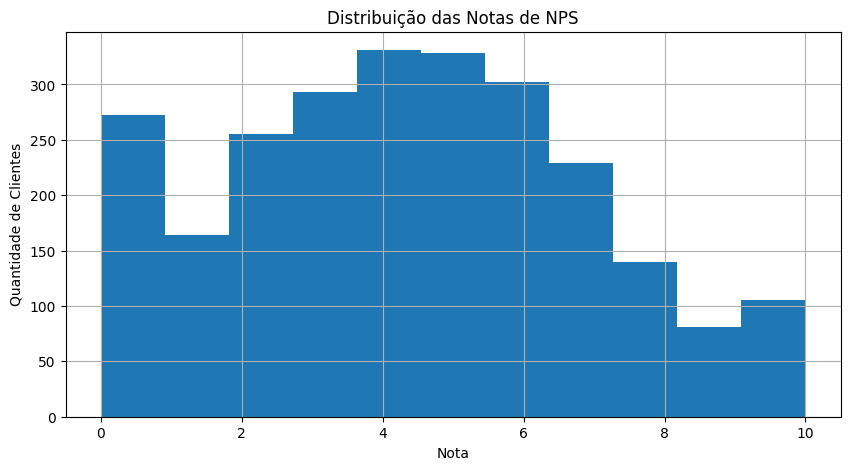

In [12]:
plt.figure(figsize=(10,5))

df['nps_score'].hist(bins=11)

plt.title('Distribuição das Notas de NPS')
plt.xlabel('Nota')
plt.ylabel('Quantidade de Clientes')

plt.show()

## **6. Análise Exploratória dos Dados (EDA)**

### **6.1 Impacto da Logística**
Nesta etapa são analisados os indicadores logísticos para verificar sua relação com a satisfação dos clientes.

In [13]:
df.groupby('nps_categoria')['delivery_delay_days'].mean()

,delivery_delay_days
nps_categoria,
Detrator,2.534306
Neutro,1.395089
Promotor,0.756219


In [14]:
df.groupby('nps_categoria')['delivery_time_days'].mean()

,delivery_time_days
nps_categoria,
Detrator,7.995678
Neutro,8.120536
Promotor,8.044776


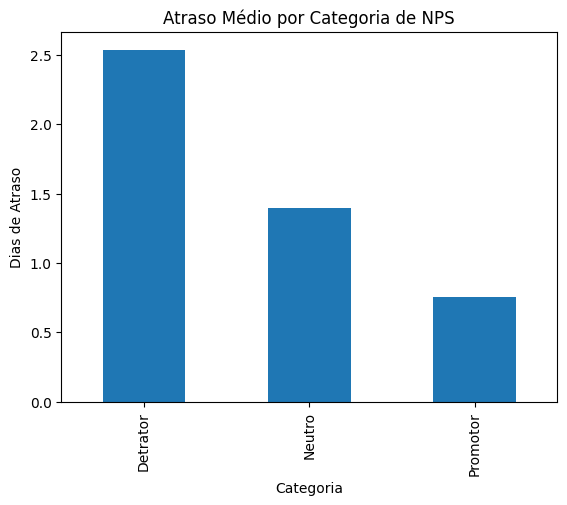

In [15]:
df.groupby('nps_categoria')['delivery_delay_days'].mean().plot(kind='bar')

plt.title('Atraso Médio por Categoria de NPS')
plt.xlabel('Categoria')
plt.ylabel('Dias de Atraso')

plt.show()

### **6.2 Atendimento ao Cliente**
Nesta etapa são analisados indicadores relacionados ao atendimento ao cliente.

In [16]:
df.groupby('nps_categoria')['customer_service_contacts'].mean()

,customer_service_contacts
nps_categoria,
Detrator,1.694219
Neutro,1.129464
Promotor,0.781095


In [17]:
df.groupby('nps_categoria')['complaints_count'].mean()

,complaints_count
nps_categoria,
Detrator,4.622907
Neutro,2.986607
Promotor,2.393035


In [18]:
df.groupby('nps_categoria')['resolution_time_days'].mean()

,resolution_time_days
nps_categoria,
Detrator,5.793625
Neutro,4.832589
Promotor,4.104478


In [19]:
df.groupby('nps_categoria')['csat_internal_score'].mean()

,csat_internal_score
nps_categoria,
Detrator,2.340465
Neutro,4.230357
Promotor,5.604975


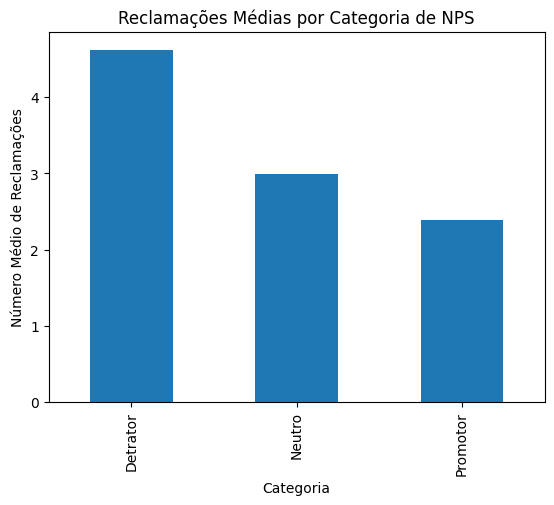

In [20]:
df.groupby('nps_categoria')['complaints_count'].mean().plot(kind='bar')

plt.title('Reclamações Médias por Categoria de NPS')
plt.xlabel('Categoria')
plt.ylabel('Número Médio de Reclamações')

plt.show()

### **6.3 Correlação entre Variáveis**
Foi calculada a correlação entre as variáveis numéricas e o NPS para identificar quais apresentam maior associação linear com a satisfação do cliente.

In [21]:
correlacoes = df.corr(numeric_only=True)['nps_score'].sort_values()
correlacoes

,nps_score
delivery_delay_days,-0.597260
complaints_count,-0.496800
customer_service_contacts,-0.350845
resolution_time_days,-0.191392
freight_value,-0.041087
customer_age,-0.009936
customer_tenure_months,-0.009711
delivery_time_days,0.000925
items_quantity,0.011468
customer_id,0.015162


### **6.4 Diferenças por Região**

In [22]:
df.groupby('customer_region')['nps_score'].mean().sort_values()

,nps_score
customer_region,
Centro-Oeste,4.209829
Sudeste,4.373846
Norte,4.382609
Nordeste,4.421649
Sul,4.490979


### **6.5 Recompra e Fidelização**

In [23]:
df.groupby('repeat_purchase_30d')['nps_score'].mean()

,nps_score
repeat_purchase_30d,
0,3.936196
1,9.009633


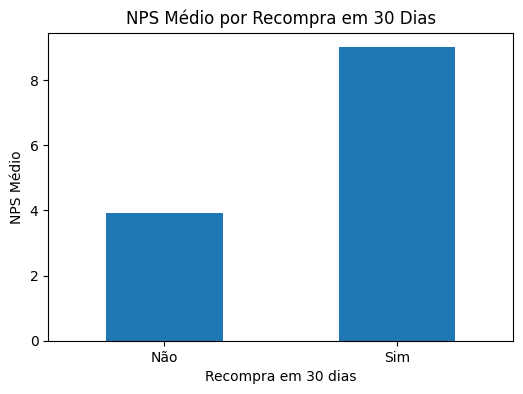

In [24]:
nps_recompra = df.groupby('repeat_purchase_30d')['nps_score'].mean()

plt.figure(figsize=(6,4))
nps_recompra.plot(kind='bar')

plt.title('NPS Médio por Recompra em 30 Dias')
plt.xlabel('Recompra em 30 dias')
plt.ylabel('NPS Médio')

plt.xticks([0,1], ['Não', 'Sim'], rotation=0)

plt.show()

### **6.6 Ponto de Ruptura da Experiência**

In [25]:
df.groupby('delivery_delay_days')['nps_score'].mean()

,nps_score
delivery_delay_days,
0,6.856679
1,5.546179
2,4.580186
3,3.436762
4,2.444444
5,1.481034
6,1.097059
7,0.292857
8,0.000000


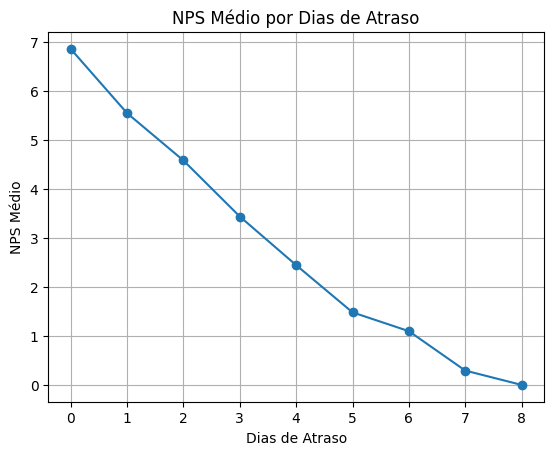

In [26]:
df.groupby('delivery_delay_days')['nps_score'].mean().plot(marker='o')

plt.title('NPS Médio por Dias de Atraso')
plt.xlabel('Dias de Atraso')
plt.ylabel('NPS Médio')

plt.grid(True)

plt.show()

## **7. Modelo Preditivo**
Como complemento à análise exploratória, foi desenvolvido um modelo de classificação utilizando Random Forest para prever a categoria de satisfação dos clientes.

### **7.1 Definição da variável alvo e das variáveis de entrada**

In [27]:
features = [
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
    'delivery_time_days',
    'order_value',
    'items_quantity',
    'customer_tenure_months',
    'customer_age'
]

X = df[features]
y = df['nps_categoria']

### **7.2 Separação treino/teste**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### **7.3 Treinamento**

In [29]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [30]:
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### **7.4 Predição**

In [31]:
y_pred = modelo.predict(X_test)

### **7.5 Avaliação**

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Detrator       0.81      0.96      0.88       363
      Neutro       0.53      0.23      0.33        98
    Promotor       0.48      0.28      0.35        39

    accuracy                           0.77       500
   macro avg       0.61      0.49      0.52       500
weighted avg       0.73      0.77      0.73       500



In [33]:
confusion_matrix(y_test, y_pred)

array([[350,  11,   2],
       [ 65,  23,  10],
       [ 19,   9,  11]])

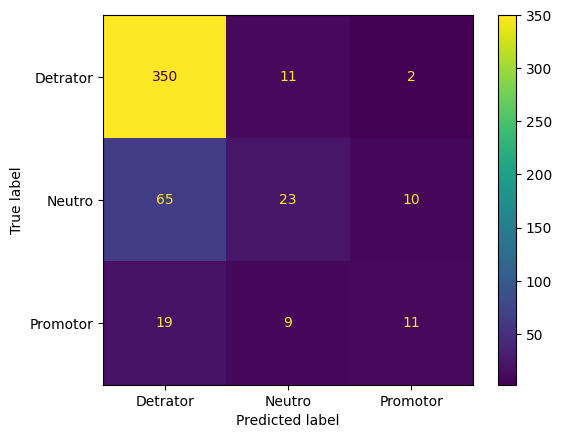

In [34]:
ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test,
    y_test
)

plt.show()

### **7.6 Importância das Variáveis**

In [35]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importancias)

complaints_count             0.199234
order_value                  0.132607
customer_tenure_months       0.123273
delivery_delay_days          0.123250
customer_age                 0.122954
resolution_time_days         0.091810
delivery_time_days           0.083344
customer_service_contacts    0.061783
items_quantity               0.061745
dtype: float64


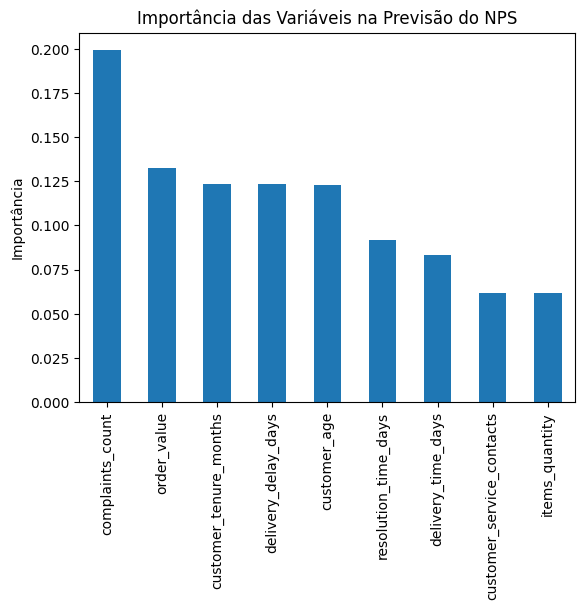

In [36]:
importancias.plot(kind='bar')

plt.title('Importância das Variáveis na Previsão do NPS')
plt.ylabel('Importância')

plt.show()